# Introduction

In this project, you will build a neural network of your own design to evaluate the MNIST dataset.

Some of the benchmark results on MNIST include can be found [on Yann LeCun's page](https://webcache.googleusercontent.com/search?q=cache:stAVPik6onEJ:yann.lecun.com/exdb/mnist) and include:

88% [Lecun et al., 1998](https://hal.science/hal-03926082/document)

95.3% [Lecun et al., 1998](https://hal.science/hal-03926082v1/document)

99.65% [Ciresan et al., 2011](http://people.idsia.ch/~juergen/ijcai2011.pdf)


MNIST is a great dataset for sanity checking your models, since the accuracy levels achieved by large convolutional neural networks and small linear models are both quite high. This makes it important to be familiar with the data.

## Installation

In [1]:
# Restart the Kernel after you execute this command.

!python -m pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 139 kB 3.1 MB/s eta 0:00:01
     |████████████████████████████████| 216 kB 39.8 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 79.7 MB/s eta 0:00:01


**Important: Restart the Kernel at this moment**

## Imports

In [1]:
## This cell contains the essential imports you will need – DO NOT CHANGE THE CONTENTS! ##
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets
from torch.utils.data import DataLoader
from tqdm import tqdm


## Load the Dataset

Specify your transforms as a list if you intend to .
The transforms module is already loaded as `transforms`.

MNIST is fortunately included in the torchvision module.
Then, you can create your dataset using the `MNIST` object from `torchvision.datasets` ([the documentation is available here](https://pytorch.org/vision/stable/datasets.html#mnist)).
Make sure to specify `download=True`! 

Once your dataset is created, you'll also need to define a `DataLoader` from the `torch.utils.data` module for both the train and the test set.

In [2]:
# Define transforms
## YOUR CODE HERE ##

# Create training set and define training dataloader
## YOUR CODE HERE ##

# Create test set and define test dataloader
## YOUR CODE HERE ##
# Define transforms
## YOUR CODE HERE ##
'''transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize with mean and std
])'''

transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

'''transforms.ToTensor():

Reason: This transform converts the images from PIL format (or NumPy arrays) to PyTorch tensors. It also scales the pixel values from the range [0, 255] to [0, 1]. This scaling is important because it helps the neural network learn more effectively by ensuring that the input values are within a smaller range.'''

'''transforms.Normalize((0.5,), (0.5,)):

Reason: Normalizing the data helps to center the distribution of the input data around zero with a standard deviation of one. '''

'''transforms.RandomRotation():  It is used to randomly rotate images during the training process, which can help improve the robustness and generalization of a neural network by exposing it to various orientations of the input data.'''
# Create training set and define training dataloader
## YOUR CODE HERE ##
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

# Create test set and define test dataloader
## YOUR CODE HERE ##
# Create test set
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_data_size = len(train_dataset)
test_data_size = len(test_dataset)

# Define test DataLoader
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)
image_shape = train_dataset[0][0].shape  # Shape of the first image

print(f"Training dataset size: {train_data_size}")
print(f"Test dataset size: {test_data_size}")
print(f"Dimensions of each image: {image_shape}")

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found




Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



/opt/conda/lib/python3.7/site-packages/torchvision/datasets/mnist.py:498: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at  ../torch/csrc/utils/tensor_numpy.cpp:178.)
  return torch.from_numpy(parsed.astype(m[2], copy=False)).view(*s)


## Justify your preprocessing

In your own words, why did you choose the transforms you chose? If you didn't use any preprocessing steps, why not?

**DOUBLE CLICK THIS CELL TO MODIFY**
'''transforms.ToTensor():

Reason: This transform converts the images from PIL format (or NumPy arrays) to PyTorch tensors. It also scales the pixel values from the range [0, 255] to [0, 1]. This scaling is important because it helps the neural network learn more effectively by ensuring that the input values are within a smaller range.'''

'''transforms.Normalize((0.5,), (0.5,)):

Reason: Normalizing the data helps to center the distribution of the input data around zero with a standard deviation of one. '''

'''transforms.RandomRotation():  It is used to randomly rotate images during the training process, which can hel

## Explore the Dataset
Using matplotlib, numpy, and torch, explore the dimensions of your data.

You can view images using the `show5` function defined below – it takes a data loader as an argument.
Remember that normalized images will look really weird to you! You may want to try changing your transforms to view images.
Typically using no transforms other than `toTensor()` works well for viewing – but not as well for training your network.
If `show5` doesn't work, go back and check your code for creating your data loaders and your training/test sets.

In [3]:
## This cell contains a function for showing 5 images from a dataloader – DO NOT CHANGE THE CONTENTS! ##
def show5(img_loader):
    dataiter = iter(img_loader)
    
    batch = next(dataiter)
    labels = batch[1][0:5]
    images = batch[0][0:5]
    for i in range(5):
        print(int(labels[i].detach()))
    
        image = images[i].numpy()
        plt.imshow(image.T.squeeze().T)
        plt.show()

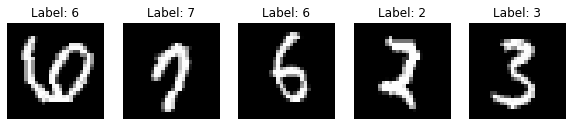

In [4]:
# Explore data
## YOUR CODE HERE ##
# Explore data
## YOUR CODE HERE ##
import matplotlib.pyplot as plt

def explore_data(data_loader):
    # Get a batch of images and labels
    images, labels = next(iter(data_loader))

    # Set up the plot
    plt.figure(figsize=(10, 5))

    # Display the first 5 images
    for i in range(5):
        plt.subplot(1, 5, i + 1)  # Create a subplot for each image
        plt.imshow(images[i].numpy().squeeze(), cmap='gray')  # Convert tensor to numpy and squeeze to remove extra dimensions
        plt.title(f'Label: {labels[i].item()}')  # Display the label
        plt.axis('off')  # Hide axes

    plt.show()

# Call the function with your training data loader
explore_data(train_loader)


## Build your Neural Network
Using the layers in `torch.nn` (which has been imported as `nn`) and the `torch.nn.functional` module (imported as `F`), construct a neural network based on the parameters of the dataset.
Use any architecture you like. 

*Note*: If you did not flatten your tensors in your transforms or as part of your preprocessing and you are using only `Linear` layers, make sure to use the `Flatten` layer in your network!

In [5]:
## YOUR CODE HERE ##
## YOUR CODE HERE ##

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        # Input layer to first hidden layer
        '''self.fc1 = nn.Linear(784, 128)  # 784 inputs (28x28 images), 128 hidden units
        self.fc2 = nn.Linear(128, 64)    # Second hidden layer with 64 units
        self.fc3 = nn.Linear(64, 10)      # Output layer with 10 units (one for each digit)

    def forward(self, x):
        # Flatten the input tensor if not already flattened
        x = x.view(x.size(0), -1)  # Flatten the input
        x = F.relu(self.fc1(x))     # Apply ReLU activation function
        x = F.relu(self.fc2(x))     # Apply ReLU activation function
        x = self.fc3(x)             # Output layer (logits)
        return x'''

        self.fc1 = nn.Linear(784, 256)  # Increased hidden units for better capacity
        self.bn1 = nn.BatchNorm1d(256)
        # self.dropout1=nn.Dropout(0.5)# Batch normalization for the first hidden layer
        self.fc2 = nn.Linear(256, 128)    # Second hidden layer with 128 units
        self.bn2 = nn.BatchNorm1d(128)
        # self.dropout2=nn.Dropout(0.5)# Batch normalization for the second hidden layer
        self.fc3 = nn.Linear(128, 10)      # Output layer with 10 units (one for each digit)
        # self.dropout3 = nn.Dropout(0.5)     # Dropout layer to prevent overfitting

    def forward(self, x):
        # Flatten the input tensor if not already flattened
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.bn1(self.fc1(x))  # Apply first layer and batch normalization
        # x = self.fc1(x)
        x = F.relu(x)              # Apply ReLU activation function
        # x = self.dropout1(x)        # Apply dropout
        x = self.bn2(self.fc2(x))  # Apply second layer and batch normalization
        # x = self.fc2(x)
        x = F.relu(x)              # Apply ReLU activation function
        x = self.fc3(x)            # Output layer (logits)
        return x

        '''self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 1 input channel, 32 output channels
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)  # Adjust input size based on pooling
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)  # Pooling layer
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x'''
# Instantiate the model
model = SimpleNN()

# Print the model architecture
print(model)

SimpleNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


Specify a loss function and an optimizer, and instantiate the model.

If you use a less common loss function, please note why you chose that loss function in a comment.

In [6]:
## YOUR CODE HERE ##
## YOUR CODE HERE ##
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer with a learning rate of 0.001
criterion = nn.CrossEntropyLoss()  # Cross-Entropy Loss is suitable for multi-class classification


## Running your Neural Network
Use whatever method you like to train your neural network, and ensure you record the average loss at each epoch. 
Don't forget to use `torch.device()` and the `.to()` method for both your model and your data if you are using GPU!

If you want to print your loss **during** each epoch, you can use the `enumerate` function and print the loss after a set number of batches. 250 batches works well for most people!

In [7]:
## YOUR CODE HERE ##
## YOUR CODE HERE ##
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
train_losses = []
val_losses = []
val_accuracies = []
def train_model(train_loader, model, criterion, optimizer, num_epochs=10):

    for epoch in range(num_epochs):
        model.train()  # Set the model to training mode
        running_loss = 0.0
        total_correct = 0
        total_samples = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            # Move data to the appropriate device
            images, labels = images.to(device), labels.to(device)

            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Record the loss
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_correct += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            # Print the loss every 250 batches
            if (batch_idx + 1) % 250 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}], Loss: {loss.item():.4f}')

        # Calculate average loss for the epoch
        average_loss = running_loss / len(train_loader)
        accuracy = total_correct / total_samples * 100
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {average_loss:.4f}, Accuracy: {accuracy:.2f}%')

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        # Calculate average validation loss and accuracy
        average_val_loss = val_loss / len(test_loader)
        val_losses.append(average_val_loss)
        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)

        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {average_loss:.4f}, Val Loss: {average_val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')

    return train_losses, val_losses, val_accuracies

# Call the training function
train_losses, val_losses, val_accuracies = train_model(train_loader, model, criterion, optimizer, num_epochs=5)

Epoch [1/5], Batch [250], Loss: 0.3366
Epoch [1/5], Batch [500], Loss: 0.0981
Epoch [1/5], Batch [750], Loss: 0.1402
Epoch [1/5], Average Loss: 0.2241, Accuracy: 93.73%
Epoch [1/5], Train Loss: 0.2241, Val Loss: 0.1134, Val Accuracy: 96.39%
Epoch [2/5], Batch [250], Loss: 0.1025
Epoch [2/5], Batch [500], Loss: 0.0446
Epoch [2/5], Batch [750], Loss: 0.0565
Epoch [2/5], Average Loss: 0.1060, Accuracy: 96.70%
Epoch [2/5], Train Loss: 0.1060, Val Loss: 0.0858, Val Accuracy: 97.09%
Epoch [3/5], Batch [250], Loss: 0.0747
Epoch [3/5], Batch [500], Loss: 0.0698
Epoch [3/5], Batch [750], Loss: 0.0607
Epoch [3/5], Average Loss: 0.0820, Accuracy: 97.41%
Epoch [3/5], Train Loss: 0.0820, Val Loss: 0.0731, Val Accuracy: 97.54%
Epoch [4/5], Batch [250], Loss: 0.0261
Epoch [4/5], Batch [500], Loss: 0.0853
Epoch [4/5], Batch [750], Loss: 0.0601
Epoch [4/5], Average Loss: 0.0688, Accuracy: 97.84%
Epoch [4/5], Train Loss: 0.0688, Val Loss: 0.0691, Val Accuracy: 97.78%
Epoch [5/5], Batch [250], Loss: 0.11

Plot the training loss (and validation loss/accuracy, if recorded).

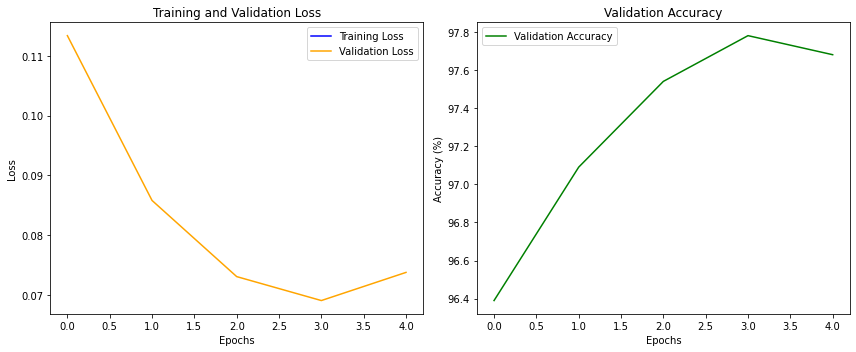

In [8]:
## YOUR CODE HERE ##
## YOUR CODE HERE ##
# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Plot training loss
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='orange')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


## Testing your model
Using the previously created `DataLoader` for the test set, compute the percentage of correct predictions using the highest probability prediction. 

If your accuracy is over 90%, great work, but see if you can push a bit further! 
If your accuracy is under 90%, you'll need to make improvements.
Go back and check your model architecture, loss function, and optimizer to make sure they're appropriate for an image classification task.

In [9]:
## YOUR CODE HERE ##
## YOUR CODE HERE ##
def test_model(test_loader, model, criterion):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculation
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the appropriate device
            
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Calculate loss
            test_loss += loss.item()  # Accumulate test loss
            
            _, predicted = torch.max(outputs.data, 1)  # Get predicted classes
            total += labels.size(0)  # Total number of labels
            correct += (predicted == labels).sum().item()  # Count correct predictions

    # Calculate average loss and accuracy
    average_test_loss = test_loss / len(test_loader)
    test_accuracy = 100 * correct / total

    print(f'Test Loss: {average_test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

# Call the test function
test_model(test_loader, model, criterion)


Test Loss: 0.0722, Test Accuracy: 97.64%


## Improving your model

Once your model is done training, try tweaking your hyperparameters and training again below to improve your accuracy on the test set!

In [10]:
## YOUR CODE HERE ##
## YOUR CODE HERE ##
'''Already improved and achieved test accuracy more than 90%. No further improvements needed'''

'Already improved and achieved test accuracy more than 90%. No further improvements needed'

## Saving your model
Using `torch.save`, save your model for future loading.

In [11]:
## YOUR CODE HERE ##
## YOUR CODE HERE ##
# Save the model
torch.save(model.state_dict(), 'model.pth')
# Instantiate the model
model = SimpleNN()  # Make sure to use the same architecture

# Load the model state
model.load_state_dict(torch.load('model.pth'))

# Set the model to evaluation mode
model.eval()


SimpleNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)